# Agriculture Analytics – Seasonal Performance Analysis

**Project Type:** Data Analytics / Business Analytics  
**Dataset:** Seasonal Agriculture Performance Dataset  
**Records Analyzed:** 4,000 farms

## Project Objective
Analyze agricultural performance across crops, seasons, irrigation methods, states, environmental factors, and production inputs to identify the strongest yield and profitability drivers and translate the findings into practical business recommendations.

> **Note:** The analysis and calculations below are preserved from the completed project. This version focuses on presentation and portfolio readiness.


In [2]:
import pandas as pd

In [3]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset (3).csv to seasonal_agriculture_performance_dataset (3).csv


In [4]:
df = pd.read_csv("seasonal_agriculture_performance_dataset (3).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 1. Dataset Overview & Validation

Inspect the dataset structure, columns, data types, missing values, duplicates, and basic consistency.

In [5]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [6]:
print("DATASET INFORMATION")
print("=" * 50)

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

DATASET INFORMATION
Shape: (4000, 28)

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenu

In [7]:
print("SEASON VALUES")
print("=" * 50)
print(df["Season"].value_counts())

print("\nCROP VALUES")
print("=" * 50)
print(df["Crop"].value_counts())

print("\nIRRIGATION METHODS")
print("=" * 50)
print(df["Irrigation_Method"].value_counts())

print("\nSTATES")
print("=" * 50)
print(df["State"].value_counts())

print("\nNUMBER OF DISTRICTS:", df["District"].nunique())

SEASON VALUES
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

CROP VALUES
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

IRRIGATION METHODS
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

STATES
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

NUMBER OF DISTRICTS: 10


In [8]:
print("NUMERICAL SUMMARY")
print("=" * 60)

display(df.describe().T)

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [10]:
print("DATA CONSISTENCY CHECK")
print("=" * 60)

# Check whether Production is approximately Farm Area × Yield
calculated_production = df["Farm_Area_Hectares"] * df["Yield_Tonnes_Ha"]

production_difference = (
    df["Production_Tonnes"] - calculated_production
).abs()

print("Production difference:")
print(production_difference.describe())

# Check whether Revenue is approximately Production × Market Price
calculated_revenue = (
    df["Production_Tonnes"] * df["Market_Price_INR_Tonne"]
)

revenue_difference = (
    df["Revenue_INR"] - calculated_revenue
).abs()

print("\nRevenue difference:")
print(revenue_difference.describe())

# Check whether Profit is approximately Revenue - Cost
calculated_profit = (
    df["Revenue_INR"] - df["Total_Cost_INR"]
)

profit_difference = (
    df["Profit_INR"] - calculated_profit
).abs()

print("\nProfit difference:")
print(profit_difference.describe())

DATA CONSISTENCY CHECK
Production difference:
count    3968.000000
mean        0.002487
std         0.001481
min         0.000000
25%         0.001200
50%         0.002500
75%         0.003800
max         0.005000
dtype: float64

Revenue difference:
count    4000.00000
mean        0.24463
std         0.14786
min         0.00000
25%         0.12000
50%         0.24000
75%         0.37000
max         0.50000
dtype: float64

Profit difference:
count    4000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64


In [11]:
print("YIELD DISTRIBUTION CHECK")
print("=" * 60)

print("Lowest 10 Yield Values:")
display(df["Yield_Tonnes_Ha"].nsmallest(10))

print("\nHighest 10 Yield Values:")
display(df["Yield_Tonnes_Ha"].nlargest(10))

print("\nYield Percentiles:")
print(df["Yield_Tonnes_Ha"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

YIELD DISTRIBUTION CHECK
Lowest 10 Yield Values:


,Yield_Tonnes_Ha
1,0.3
12,0.3
25,0.3
31,0.3
40,0.3
48,0.3
51,0.3
104,0.3
107,0.3
121,0.3



Highest 10 Yield Values:


,Yield_Tonnes_Ha
1715,101.44
3423,95.79
3525,93.13
1464,91.98
3523,91.46
2782,91.32
644,89.34
2847,87.76
357,84.75
1178,83.79



Yield Percentiles:
0.01     0.3000
0.05     0.3000
0.25     1.0500
0.50     1.7400
0.75     2.8400
0.95    38.4650
0.99    70.8233
Name: Yield_Tonnes_Ha, dtype: float64


In [12]:
print("HIGH-YIELD RECORD INVESTIGATION")
print("=" * 60)

high_yield = df.nlargest(20, "Yield_Tonnes_Ha")

display(
    high_yield[
        [
            "Farm_ID",
            "State",
            "District",
            "Crop",
            "Season",
            "Farm_Area_Hectares",
            "Yield_Tonnes_Ha",
            "Production_Tonnes",
            "Market_Price_INR_Tonne",
            "Profit_INR"
        ]
    ]
)

HIGH-YIELD RECORD INVESTIGATION


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Profit_INR
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,641.10,3077,1608291
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,3109,3330582
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,648.18,2917,1471529
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,703.65,3839,2216708
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,75.00,3898,234320
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,522.35,3316,1236801
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,668.26,3705,1984818
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,672.24,3625,2041678
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,3483,3378879
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,534.58,3060,1200815


## 2. Crop & Seasonal Yield Analysis

Compare yield performance across crops and seasons and identify major differences in agricultural productivity.

In [13]:
crop_yield = (
    df.groupby("Crop")["Yield_Tonnes_Ha"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)

display(crop_yield)

,count,mean,median,min,max
Crop,,,,,
Sugarcane,303,46.938746,48.030,1.39,101.44
Maize,547,2.717130,2.850,0.30,6.08
Rice,682,2.439413,2.460,0.30,5.70
Wheat,612,2.109216,2.225,0.30,4.56
Chilli,407,1.540344,1.560,0.30,3.90
Groundnut,419,1.317924,1.400,0.30,3.02
Cotton,504,1.225734,1.240,0.30,2.90
Pulses,494,0.918198,0.940,0.30,2.09


In [14]:
season_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)

display(season_yield)

,count,mean,median,min,max
Season,,,,,
Kharif,1772,5.643973,1.95,0.3,101.44
Rabi,1607,5.080498,1.66,0.3,93.13
Zaid,589,4.665942,1.45,0.3,64.76


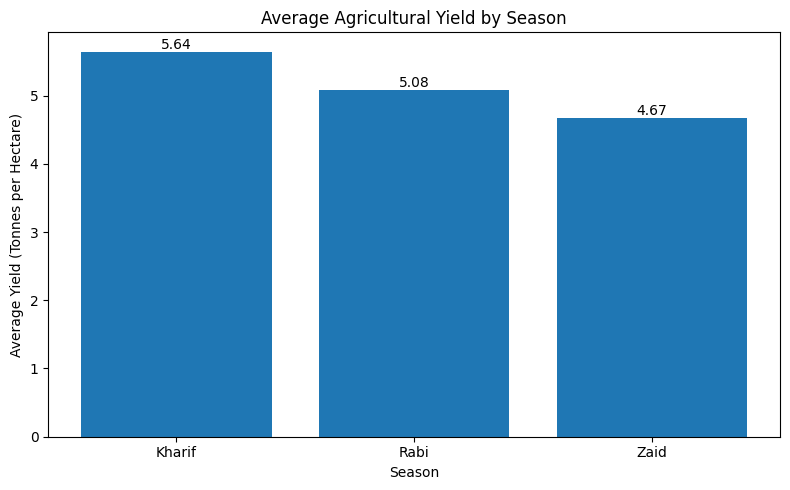

In [16]:
import matplotlib.pyplot as plt

season_avg_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    season_avg_yield.index,
    season_avg_yield.values
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes per Hectare)")

for i, value in enumerate(season_avg_yield.values):
    plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [17]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

display(crop_season_yield.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


<Figure size 1200x600 with 0 Axes>

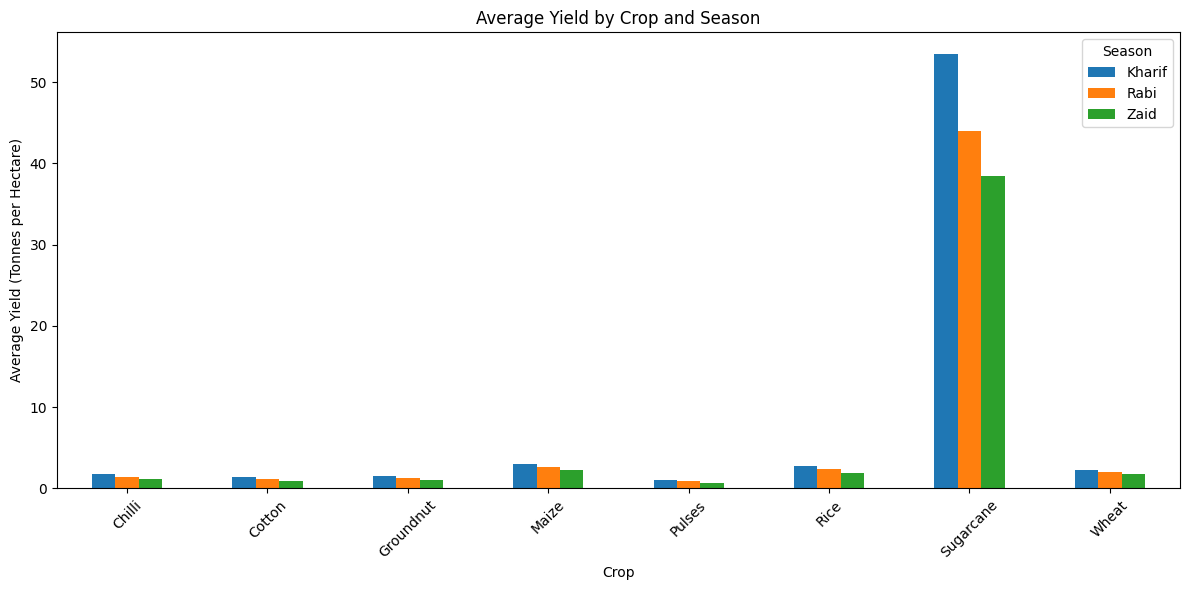

In [18]:
plt.figure(figsize=(12, 6))

crop_season_yield.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.xticks(rotation=45)
plt.legend(title="Season")

plt.tight_layout()
plt.show()

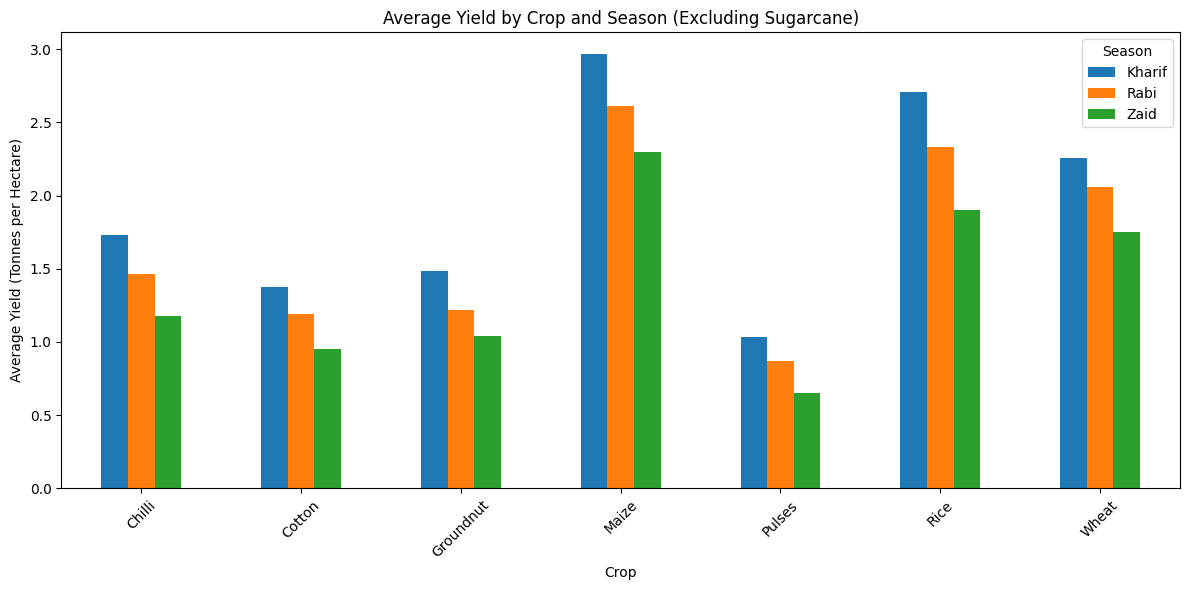

In [19]:
# Exclude Sugarcane to compare the remaining crops more clearly

other_crops = crop_season_yield.drop("Sugarcane")

other_crops.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Yield by Crop and Season (Excluding Sugarcane)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.xticks(rotation=45)
plt.legend(title="Season")

plt.tight_layout()
plt.show()

## 3. Environmental Factors & Yield Relationships

Examine the relationship between rainfall, temperature, humidity, sunlight, soil pH, soil moisture, and yield.

In [20]:
environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

environment_corr = (
    df[environment_cols]
    .corr()["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

display(environment_corr.round(3))

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000
Rainfall_mm,0.031
Humidity_pct,0.011
Soil_Moisture_pct,0.010
Avg_Temperature_C,0.009
Sunlight_Hours_Day,-0.015
Soil_pH,-0.021


In [21]:
environment_factors = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct"
]

crop_correlations = {}

for crop in df["Crop"].unique():
    crop_data = df[df["Crop"] == crop]

    correlations = (
        crop_data[environment_factors + ["Yield_Tonnes_Ha"]]
        .corr()["Yield_Tonnes_Ha"]
        .drop("Yield_Tonnes_Ha")
    )

    crop_correlations[crop] = correlations

crop_corr_df = pd.DataFrame(crop_correlations).T

display(crop_corr_df.round(3))

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Wheat,0.179,-0.017,0.161,-0.074,0.016,0.147
Maize,0.211,0.024,0.149,-0.089,-0.013,0.206
Pulses,0.240,0.010,0.194,-0.155,-0.054,0.173
Rice,0.187,0.005,0.152,-0.126,0.004,0.168
Cotton,0.235,-0.051,0.165,-0.119,-0.047,0.180
Chilli,0.204,-0.017,0.145,-0.118,0.030,0.157
Groundnut,0.237,0.044,0.103,-0.101,-0.071,0.248
Sugarcane,0.278,0.088,0.194,-0.146,0.112,0.172


## 4. Irrigation Performance

Compare irrigation methods using average yield, water usage, water efficiency, and profitability.

In [22]:
irrigation_analysis = (
    df.groupby("Irrigation_Method")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Water_Used=("Water_Used_m3", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Avg_Profit=("Profit_INR", "mean")
      )
      .sort_values("Avg_Yield", ascending=False)
)

display(irrigation_analysis.round(2))

,Farms,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
Irrigation_Method,,,,,
Drip,915,6.62,5918.75,6.27,219626.00
Sprinkler,734,5.19,6208.26,4.67,91121.08
Flood,1310,4.90,8026.47,3.44,73354.02
Rainfed,1041,4.61,3549.55,7.56,79050.37


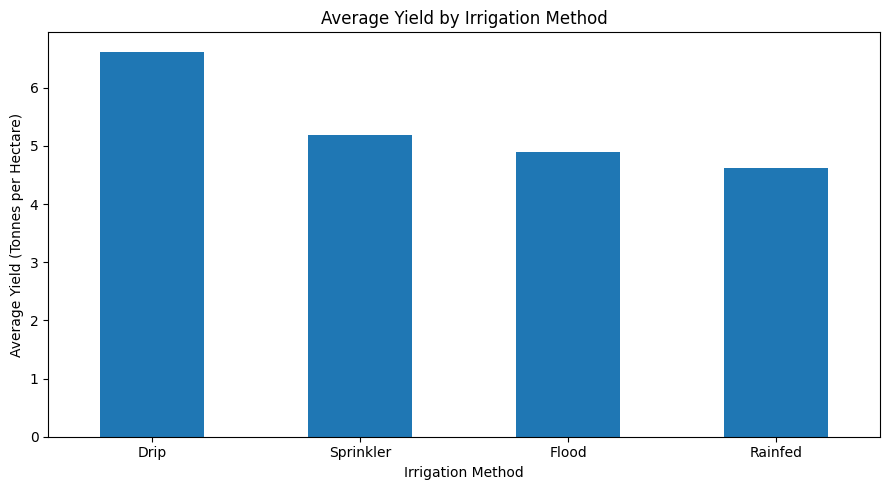

In [23]:
irrigation_analysis["Avg_Yield"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
irrigation_crop_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Irrigation_Method",
    aggfunc="mean"
)

display(irrigation_crop_yield.round(2))

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Crop,,,,
Chilli,1.72,1.49,1.44,1.50
Cotton,1.42,1.17,1.11,1.25
Groundnut,1.32,1.35,1.28,1.31
Maize,2.80,2.79,2.48,2.84
Pulses,1.05,0.88,0.86,0.89
Rice,2.77,2.24,2.36,2.49
Sugarcane,55.12,46.87,40.53,44.37
Wheat,2.30,2.03,1.98,2.23


In [25]:
irrigation_profit = (
    df.groupby("Irrigation_Method")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(irrigation_profit.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Cost,Avg_Revenue
Irrigation_Method,,,,,
Drip,915,6.62,219626.00,534945.24,754571.23
Sprinkler,734,5.19,91121.08,526609.22,617730.30
Rainfed,1041,4.61,79050.37,505303.61,584353.98
Flood,1310,4.90,73354.02,536784.13,610138.15


## 5. Crop & Seasonal Profitability

Evaluate average revenue, cost, profit, yield, and seasonal profitability by crop.

In [26]:
crop_profit = (
    df.groupby("Crop")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(crop_profit.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Cost
Crop,,,,,
Sugarcane,305,46.94,817187.99,1371980.11,554792.13
Chilli,412,1.54,750878.34,1276777.23,525898.89
Cotton,508,1.23,124546.92,639423.08,514876.17
Groundnut,424,1.32,44858.12,542935.50,498077.38
Pulses,496,0.92,-4238.05,528465.87,532703.92
Maize,551,2.72,-83978.33,457067.99,541046.32
Rice,690,2.44,-102213.50,423615.26,525828.76
Wheat,614,2.11,-123398.34,400104.89,523503.22


In [27]:
season_profit = (
    df.groupby("Season")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(season_profit.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Cost
Season,,,,,
Kharif,1779,5.64,178914.65,710719.06,531804.41
Rabi,1627,5.08,87689.47,601526.05,513836.58
Zaid,594,4.67,-24804.82,519171.90,543976.73


In [28]:
crop_season_profit = pd.pivot_table(
    df,
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

display(crop_season_profit.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


## 6. Agricultural Inputs & Yield Drivers

Measure correlations between agricultural inputs and yield to identify the strongest listed relationships.

In [29]:
input_columns = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Soil_Moisture_pct"
]

input_correlations = (
    df[input_columns + ["Yield_Tonnes_Ha"]]
    .corr()["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(ascending=False)
)

display(input_correlations.round(3))

,Yield_Tonnes_Ha
Nitrogen_kg_ha,0.054
Phosphorus_kg_ha,0.048
Soil_Moisture_pct,0.010
Potassium_kg_ha,0.004
Fertilizer_kg_ha,0.001
Seed_Quality_Score,-0.007
Pesticide_Litre_ha,-0.008


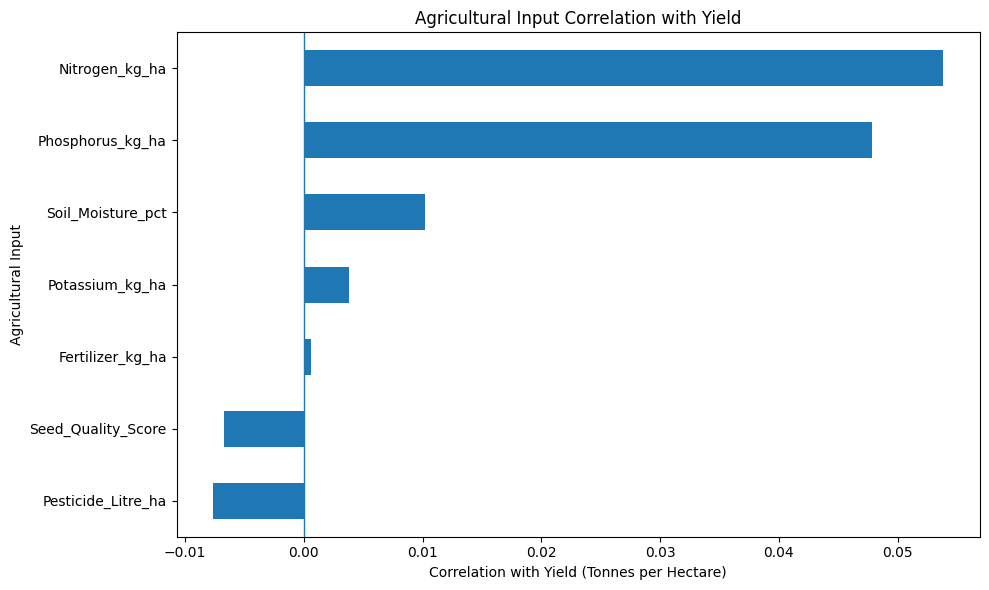

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

input_correlations.sort_values().plot(kind="barh")

plt.title("Agricultural Input Correlation with Yield")
plt.xlabel("Correlation with Yield (Tonnes per Hectare)")
plt.ylabel("Agricultural Input")

plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

## 7. Water Efficiency Analysis

Assess water consumption and water efficiency across irrigation methods.

In [31]:
water_analysis = (
    df.groupby("Irrigation_Method")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Water_Used=("Water_Used_m3", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Avg_Profit=("Profit_INR", "mean")
      )
      .sort_values("Avg_Water_Efficiency", ascending=False)
)

display(water_analysis.round(2))

,Farms,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
Irrigation_Method,,,,,
Rainfed,1041,4.61,3549.55,7.56,79050.37
Drip,915,6.62,5918.75,6.27,219626.00
Sprinkler,734,5.19,6208.26,4.67,91121.08
Flood,1310,4.90,8026.47,3.44,73354.02


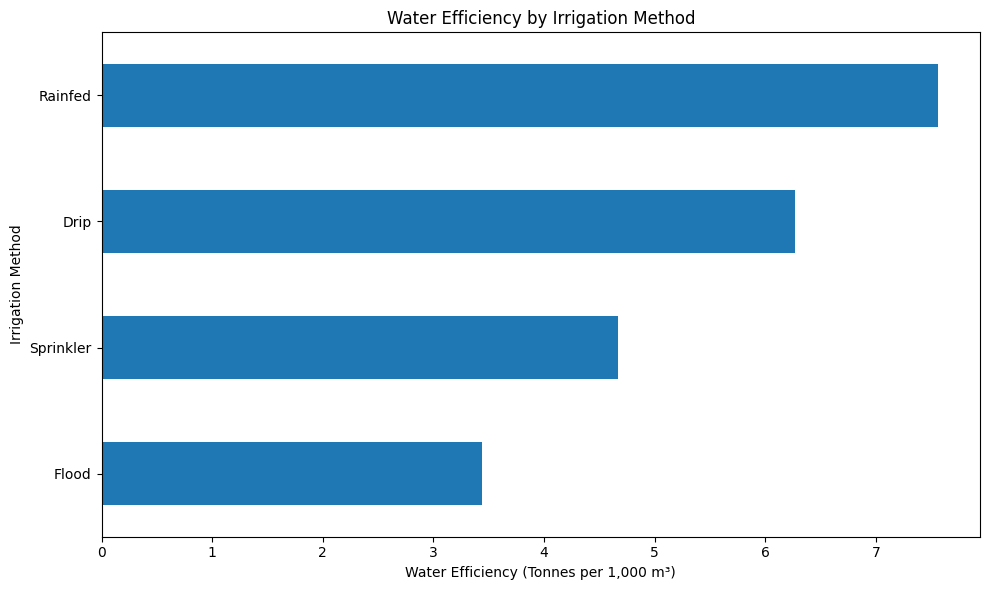

In [32]:
plt.figure(figsize=(10, 6))

water_analysis["Avg_Water_Efficiency"].sort_values().plot(kind="barh")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Water Efficiency (Tonnes per 1,000 m³)")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

## 8. State-wise Agricultural Performance

Compare states using farm count, yield, profit, revenue, cost, water use, and water efficiency.

In [33]:
# STATE-WISE PERFORMANCE ANALYSIS

state_performance = (
    df.groupby("State")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean"),
          Avg_Water_Used=("Water_Used_m3", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .sort_values("Avg_Yield", ascending=False)
)

display(state_performance.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Cost,Avg_Water_Used,Avg_Water_Efficiency
State,,,,,,,
Punjab,484,6.12,136025.64,686225.70,550200.07,6565.92,5.62
Karnataka,489,5.73,119422.34,653426.18,534003.85,6414.33,5.56
Gujarat,488,5.70,117568.24,654692.86,537124.62,6142.50,5.58
Telangana,516,5.08,108829.62,628784.53,519954.92,5801.83,5.46
Maharashtra,512,5.03,135428.86,650032.67,514603.81,5968.08,5.28
Madhya Pradesh,497,5.03,86840.76,597558.36,510717.60,5663.92,5.27
Tamil Nadu,485,4.90,117744.75,629093.42,511348.67,5775.22,5.31
Andhra Pradesh,529,4.65,73453.53,606663.66,533210.13,6058.38,5.03


## 9. State × Crop Analysis

Identify how crop performance varies across states.

In [34]:
state_crop = (
    df.groupby(["State", "Crop"])
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(state_crop.round(2))

,,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Cost
State,Crop,,,,,
Tamil Nadu,Sugarcane,31,49.62,979775.39,1566301.32,586525.94
Maharashtra,Chilli,53,1.65,929988.15,1465179.94,535191.79
Gujarat,Chilli,46,1.64,901790.22,1436027.33,534237.11
Maharashtra,Sugarcane,36,46.96,893729.31,1508215.44,614486.14
Andhra Pradesh,Sugarcane,31,50.26,867348.94,1370963.74,503614.81
...,...,...,...,...,...,...
Punjab,Rice,87,2.43,-128490.71,399322.23,527812.94
Karnataka,Rice,82,2.35,-131267.23,416944.73,548211.96
Gujarat,Maize,80,2.51,-133452.04,437276.30,570728.34


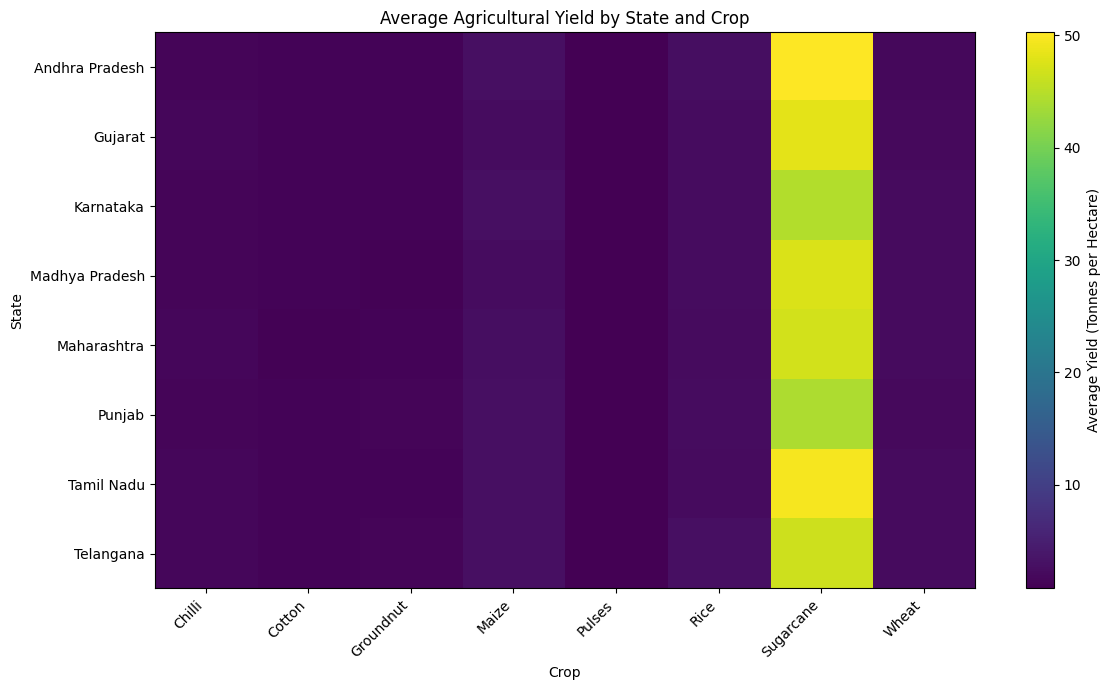

In [35]:
state_crop_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Crop",
    aggfunc="mean"
)

plt.figure(figsize=(12, 7))

plt.imshow(state_crop_yield, aspect="auto")

plt.colorbar(label="Average Yield (Tonnes per Hectare)")

plt.xticks(
    range(len(state_crop_yield.columns)),
    state_crop_yield.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(state_crop_yield.index)),
    state_crop_yield.index
)

plt.title("Average Agricultural Yield by State and Crop")
plt.xlabel("Crop")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [36]:
state_crop_profit = pd.pivot_table(
    df,
    values="Profit_INR",
    index="State",
    columns="Crop",
    aggfunc="mean"
)

display(state_crop_profit.round(0))

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
State,,,,,,,,
Andhra Pradesh,601541.0,68467.0,40227.0,-83024.0,-6006.0,-90824.0,867349.0,-168956.0
Gujarat,901790.0,63474.0,59443.0,-133452.0,17531.0,-110069.0,852212.0,-124212.0
Karnataka,760005.0,172722.0,-10364.0,-74972.0,-10536.0,-131267.0,731861.0,-105839.0
Madhya Pradesh,632344.0,202709.0,-46582.0,-95792.0,-32290.0,-112065.0,796707.0,-100792.0
Maharashtra,929988.0,88225.0,82103.0,-73095.0,23266.0,-100510.0,893729.0,-116614.0
Punjab,717282.0,131382.0,146199.0,-66806.0,23741.0,-128491.0,747372.0,-152086.0
Tamil Nadu,747758.0,144091.0,72078.0,-74603.0,-78478.0,-114470.0,979775.0,-95790.0
Telangana,730055.0,133434.0,35152.0,-66051.0,29410.0,-35092.0,738184.0,-119073.0


## 10. Crop Profit Margin Analysis

Calculate and rank crop-level profit margins using average profit and average revenue.

In [37]:
crop_margin = (
    df.groupby("Crop")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean"),
          Avg_Profit=("Profit_INR", "mean")
      )
)

crop_margin["Profit_Margin_pct"] = (
    crop_margin["Avg_Profit"] /
    crop_margin["Avg_Revenue"] * 100
)

crop_margin = crop_margin.sort_values(
    "Profit_Margin_pct",
    ascending=False
)

display(crop_margin.round(2))

,Farms,Avg_Revenue,Avg_Cost,Avg_Profit,Profit_Margin_pct
Crop,,,,,
Sugarcane,305,1371980.11,554792.13,817187.99,59.56
Chilli,412,1276777.23,525898.89,750878.34,58.81
Cotton,508,639423.08,514876.17,124546.92,19.48
Groundnut,424,542935.50,498077.38,44858.12,8.26
Pulses,496,528465.87,532703.92,-4238.05,-0.80
Maize,551,457067.99,541046.32,-83978.33,-18.37
Rice,690,423615.26,525828.76,-102213.50,-24.13
Wheat,614,400104.89,523503.22,-123398.34,-30.84


## 11. Profit Driver Analysis

Examine the relationship between agricultural inputs, production economics, revenue, cost, yield, and profit.

In [38]:
profit_correlations = (
    df[
        [
            "Nitrogen_kg_ha",
            "Phosphorus_kg_ha",
            "Potassium_kg_ha",
            "Fertilizer_kg_ha",
            "Pesticide_Litre_ha",
            "Seed_Quality_Score",
            "Water_Used_m3",
            "Water_Efficiency_t_per_1000m3",
            "Profit_INR"
        ]
    ]
    .corr()["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(ascending=False)
)

display(profit_correlations.round(3))

,Profit_INR
Water_Efficiency_t_per_1000m3,0.489
Water_Used_m3,0.190
Nitrogen_kg_ha,0.085
Phosphorus_kg_ha,0.050
Potassium_kg_ha,0.031
Seed_Quality_Score,0.010
Pesticide_Litre_ha,-0.026
Fertilizer_kg_ha,-0.074


In [39]:
economic_correlations = (
    df[
        [
            "Yield_Tonnes_Ha",
            "Market_Price_INR_Tonne",
            "Production_Tonnes",
            "Revenue_INR",
            "Total_Cost_INR",
            "Profit_INR"
        ]
    ]
    .corr()
    .round(3)
)

display(economic_correlations)

,Yield_Tonnes_Ha,Market_Price_INR_Tonne,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Yield_Tonnes_Ha,1.000,-0.384,0.885,0.434,0.031,0.490
Market_Price_INR_Tonne,-0.384,1.000,-0.338,0.182,-0.022,0.225
Production_Tonnes,0.885,-0.338,1.000,0.564,0.193,0.554
Revenue_INR,0.434,0.182,0.564,1.000,0.521,0.887
Total_Cost_INR,0.031,-0.022,0.193,0.521,1.000,0.068
Profit_INR,0.490,0.225,0.554,0.887,0.068,1.000


In [40]:
print("PROFIT DRIVER ANALYSIS")
print("=" * 60)

profit_correlations = (
    df[
        [
            "Yield_Tonnes_Ha",
            "Market_Price_INR_Tonne",
            "Production_Tonnes",
            "Revenue_INR",
            "Total_Cost_INR",
            "Profit_INR"
        ]
    ]
    .corr()["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(ascending=False)
)

print("\nCorrelation with Profit:")
display(profit_correlations.round(3))

PROFIT DRIVER ANALYSIS

Correlation with Profit:


,Profit_INR
Revenue_INR,0.887
Production_Tonnes,0.554
Yield_Tonnes_Ha,0.490
Market_Price_INR_Tonne,0.225
Total_Cost_INR,0.068


## 12. Crop × Irrigation Profitability

Compare average profit for each crop under different irrigation methods.

In [41]:
print("PROFIT BY CROP AND IRRIGATION METHOD")
print("=" * 60)

crop_irrigation_profit = pd.pivot_table(
    df,
    values="Profit_INR",
    index="Crop",
    columns="Irrigation_Method",
    aggfunc="mean"
)

display(crop_irrigation_profit.round(2))

PROFIT BY CROP AND IRRIGATION METHOD


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Crop,,,,
Chilli,928384.62,711364.95,681957.72,663959.41
Cotton,216221.93,98469.29,89389.10,109928.16
Groundnut,44135.02,38413.31,47721.99,53153.84
Maize,-74456.36,-83099.18,-87571.08,-93008.25
Pulses,73814.10,-23883.35,-2857.79,-64285.33
Rice,-26225.31,-159931.40,-102519.01,-91879.78
Sugarcane,1112871.15,752213.89,620287.30,765585.98
Wheat,-87602.79,-153512.17,-121241.08,-109864.11


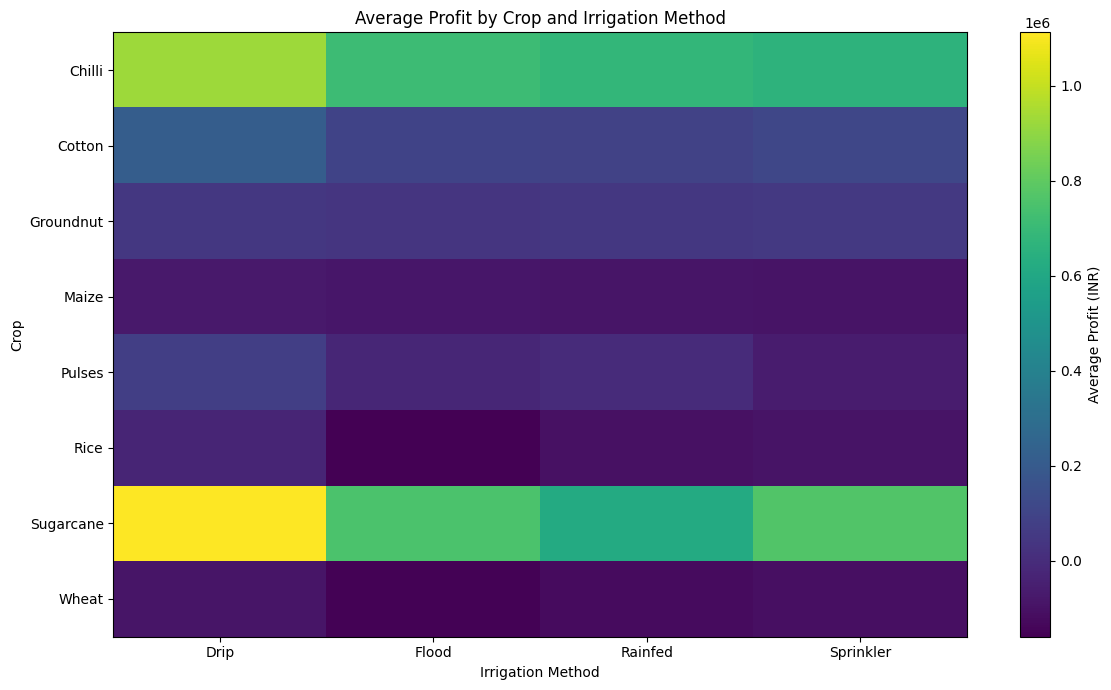

In [42]:
plt.figure(figsize=(12, 7))

plt.imshow(crop_irrigation_profit, aspect="auto")

plt.colorbar(label="Average Profit (INR)")

plt.xticks(
    range(len(crop_irrigation_profit.columns)),
    crop_irrigation_profit.columns
)

plt.yticks(
    range(len(crop_irrigation_profit.index)),
    crop_irrigation_profit.index
)

plt.title("Average Profit by Crop and Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

## 13. Reliable State × Crop × Irrigation Combinations

Focus on combinations with at least 10 farms to reduce the influence of very small groups.

In [43]:
print("TOP STATE + CROP + IRRIGATION COMBINATIONS")
print("=" * 60)

state_crop_irrigation = (
    df.groupby(["State", "Crop", "Irrigation_Method"])
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(state_crop_irrigation.head(20).round(2))

TOP STATE + CROP + IRRIGATION COMBINATIONS


,,,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Cost
State,Crop,Irrigation_Method,,,,,
Andhra Pradesh,Sugarcane,Drip,5,79.28,1826447.40,2420124.20,593676.80
Telangana,Chilli,Rainfed,8,1.92,1449641.75,2120129.00,670487.25
Gujarat,Sugarcane,Drip,15,61.71,1409635.80,2009490.33,599854.53
Tamil Nadu,Sugarcane,Drip,7,51.26,1280084.86,1987871.43,707786.57
Gujarat,Chilli,Sprinkler,9,2.05,1222477.33,1699404.67,476927.33
Madhya Pradesh,Sugarcane,Drip,11,53.33,1192468.18,1725681.64,533213.45
Punjab,Chilli,Flood,18,1.65,1162920.11,1697580.78,534660.67
Tamil Nadu,Chilli,Drip,15,2.06,1139191.47,1670293.07,531101.60
Maharashtra,Sugarcane,Rainfed,9,47.18,1095264.89,1671303.00,576038.11


In [44]:
print("RELIABLE TOP STATE + CROP + IRRIGATION COMBINATIONS")
print("=" * 70)

reliable_combinations = (
    state_crop_irrigation[
        state_crop_irrigation["Farms"] >= 10
    ]
    .sort_values("Avg_Profit", ascending=False)
)

display(
    reliable_combinations
    .head(15)
    .round(2)
)

RELIABLE TOP STATE + CROP + IRRIGATION COMBINATIONS


,,,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Cost
State,Crop,Irrigation_Method,,,,,
Gujarat,Sugarcane,Drip,15,61.71,1409635.80,2009490.33,599854.53
Madhya Pradesh,Sugarcane,Drip,11,53.33,1192468.18,1725681.64,533213.45
Punjab,Chilli,Flood,18,1.65,1162920.11,1697580.78,534660.67
Tamil Nadu,Chilli,Drip,15,2.06,1139191.47,1670293.07,531101.60
Karnataka,Chilli,Drip,13,1.55,1078630.62,1665831.08,587200.46
Gujarat,Chilli,Drip,10,1.59,1042875.70,1532142.60,489266.90
Maharashtra,Chilli,Rainfed,10,1.51,1011762.20,1460578.00,448815.80
Tamil Nadu,Sugarcane,Rainfed,11,45.22,1001951.91,1712536.91,710585.00
Telangana,Chilli,Drip,13,1.89,980540.92,1464838.69,484297.77


## 14. Profit Margin of Reliable Combinations

Rank sufficiently represented state–crop–irrigation combinations by profit margin.

In [45]:
print("PROFIT MARGIN ANALYSIS — RELIABLE COMBINATIONS")
print("=" * 70)

reliable_margin = reliable_combinations.copy()

reliable_margin["Profit_Margin_pct"] = (
    reliable_margin["Avg_Profit"] /
    reliable_margin["Avg_Revenue"] * 100
)

display(
    reliable_margin[
        [
            "Farms",
            "Avg_Yield",
            "Avg_Revenue",
            "Avg_Cost",
            "Avg_Profit",
            "Profit_Margin_pct"
        ]
    ]
    .sort_values("Profit_Margin_pct", ascending=False)
    .head(15)
    .round(2)
)

PROFIT MARGIN ANALYSIS — RELIABLE COMBINATIONS


,,,Farms,Avg_Yield,Avg_Revenue,Avg_Cost,Avg_Profit,Profit_Margin_pct
State,Crop,Irrigation_Method,,,,,,
Gujarat,Sugarcane,Drip,15,61.71,2009490.33,599854.53,1409635.80,70.15
Maharashtra,Chilli,Rainfed,10,1.51,1460578.00,448815.80,1011762.20,69.27
Madhya Pradesh,Sugarcane,Drip,11,53.33,1725681.64,533213.45,1192468.18,69.10
Punjab,Chilli,Flood,18,1.65,1697580.78,534660.67,1162920.11,68.50
Tamil Nadu,Chilli,Drip,15,2.06,1670293.07,531101.60,1139191.47,68.20
Gujarat,Chilli,Drip,10,1.59,1532142.60,489266.90,1042875.70,68.07
Telangana,Chilli,Drip,13,1.89,1464838.69,484297.77,980540.92,66.94
Karnataka,Chilli,Drip,13,1.55,1665831.08,587200.46,1078630.62,64.75
Telangana,Sugarcane,Flood,11,52.33,1204293.09,431645.91,772647.18,64.16


## 15. Final Business Recommendations

Translate the analysis into actionable recommendations for crop selection, irrigation decisions, and resource allocation.

In [47]:
# FINAL BUSINESS RECOMMENDATIONS
print("FINAL BUSINESS RECOMMENDATIONS")
print("=" * 60)

# 1. Crop profitability
crop_profit_final = (
    df.groupby("Crop")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

# 2. Irrigation profitability
irrigation_final = (
    df.groupby("Irrigation_Method")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Water_Used=("Water_Used_m3", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Avg_Profit=("Profit_INR", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

# 3. Crop profit margin
crop_margin_final = crop_profit_final.copy()
crop_margin_final["Profit_Margin_pct"] = (
    crop_margin_final["Avg_Profit"] /
    crop_margin_final["Avg_Revenue"] * 100
)

# 4. Reliable state + crop + irrigation combinations
reliable_final = (
    df.groupby(["State", "Crop", "Irrigation_Method"])
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Revenue=("Revenue_INR", "mean"),
          Avg_Cost=("Total_Cost_INR", "mean")
      )
      .reset_index()
)

# Keep combinations with enough farms
reliable_final = reliable_final[reliable_final["Farms"] >= 10].copy()

reliable_final["Profit_Margin_pct"] = (
    reliable_final["Avg_Profit"] /
    reliable_final["Avg_Revenue"] * 100
)

reliable_final = reliable_final.sort_values(
    "Profit_Margin_pct",
    ascending=False
)

# --------------------------------------------------
# RESULTS
# --------------------------------------------------

best_crop = crop_profit_final.iloc[0]
best_irrigation = irrigation_final.iloc[0]
best_combination = reliable_final.iloc[0]

print("\n1. MOST PROFITABLE CROP")
print("-" * 40)
print(f"Crop: {best_crop.name}")
print(f"Average Yield: {best_crop['Avg_Yield']:.2f} tonnes/ha")
print(f"Average Profit: ₹{best_crop['Avg_Profit']:,.2f}")
print(
    f"Profit Margin: "
    f"{crop_margin_final.loc[best_crop.name, 'Profit_Margin_pct']:.2f}%"
)

print("\n2. BEST IRRIGATION METHOD BY PROFIT")
print("-" * 40)
print(f"Method: {best_irrigation.name}")
print(f"Average Yield: {best_irrigation['Avg_Yield']:.2f} tonnes/ha")
print(f"Average Profit: ₹{best_irrigation['Avg_Profit']:,.2f}")
print(
    f"Water Efficiency: "
    f"{best_irrigation['Avg_Water_Efficiency']:.2f}"
)

print("\n3. BEST RELIABLE STATE + CROP + IRRIGATION")
print("-" * 40)
print(f"State: {best_combination['State']}")
print(f"Crop: {best_combination['Crop']}")
print(f"Irrigation: {best_combination['Irrigation_Method']}")
print(f"Farms: {best_combination['Farms']}")
print(f"Average Yield: {best_combination['Avg_Yield']:.2f} tonnes/ha")
print(f"Average Profit: ₹{best_combination['Avg_Profit']:,.2f}")
print(f"Profit Margin: {best_combination['Profit_Margin_pct']:.2f}%")

print("\n4. KEY YIELD DRIVER")
print("-" * 40)
print("Nitrogen has the strongest positive correlation with yield.")

print("\n5. KEY PROFIT DRIVER")
print("-" * 40)
print("Revenue has the strongest correlation with profit.")

print("\n6. BUSINESS RECOMMENDATION")
print("-" * 40)
print(
    "Prioritize high-margin crops such as Sugarcane and Chilli, "
    "evaluate irrigation using both profitability and water efficiency, "
    "and focus on reliable state-crop-irrigation combinations."
)

FINAL BUSINESS RECOMMENDATIONS

1. MOST PROFITABLE CROP
----------------------------------------
Crop: Sugarcane
Average Yield: 46.94 tonnes/ha
Average Profit: ₹817,187.99
Profit Margin: 59.56%

2. BEST IRRIGATION METHOD BY PROFIT
----------------------------------------
Method: Drip
Average Yield: 6.62 tonnes/ha
Average Profit: ₹219,626.00
Water Efficiency: 6.27

3. BEST RELIABLE STATE + CROP + IRRIGATION
----------------------------------------
State: Gujarat
Crop: Sugarcane
Irrigation: Drip
Farms: 15
Average Yield: 61.71 tonnes/ha
Average Profit: ₹1,409,635.80
Profit Margin: 70.15%

4. KEY YIELD DRIVER
----------------------------------------
Nitrogen has the strongest positive correlation with yield.

5. KEY PROFIT DRIVER
----------------------------------------
Revenue has the strongest correlation with profit.

6. BUSINESS RECOMMENDATION
----------------------------------------
Prioritize high-margin crops such as Sugarcane and Chilli, evaluate irrigation using both profitability

## 16. Executive Dashboard

A consolidated dashboard summarizing crop profitability, irrigation yield, state profitability, and crop–irrigation profit patterns.

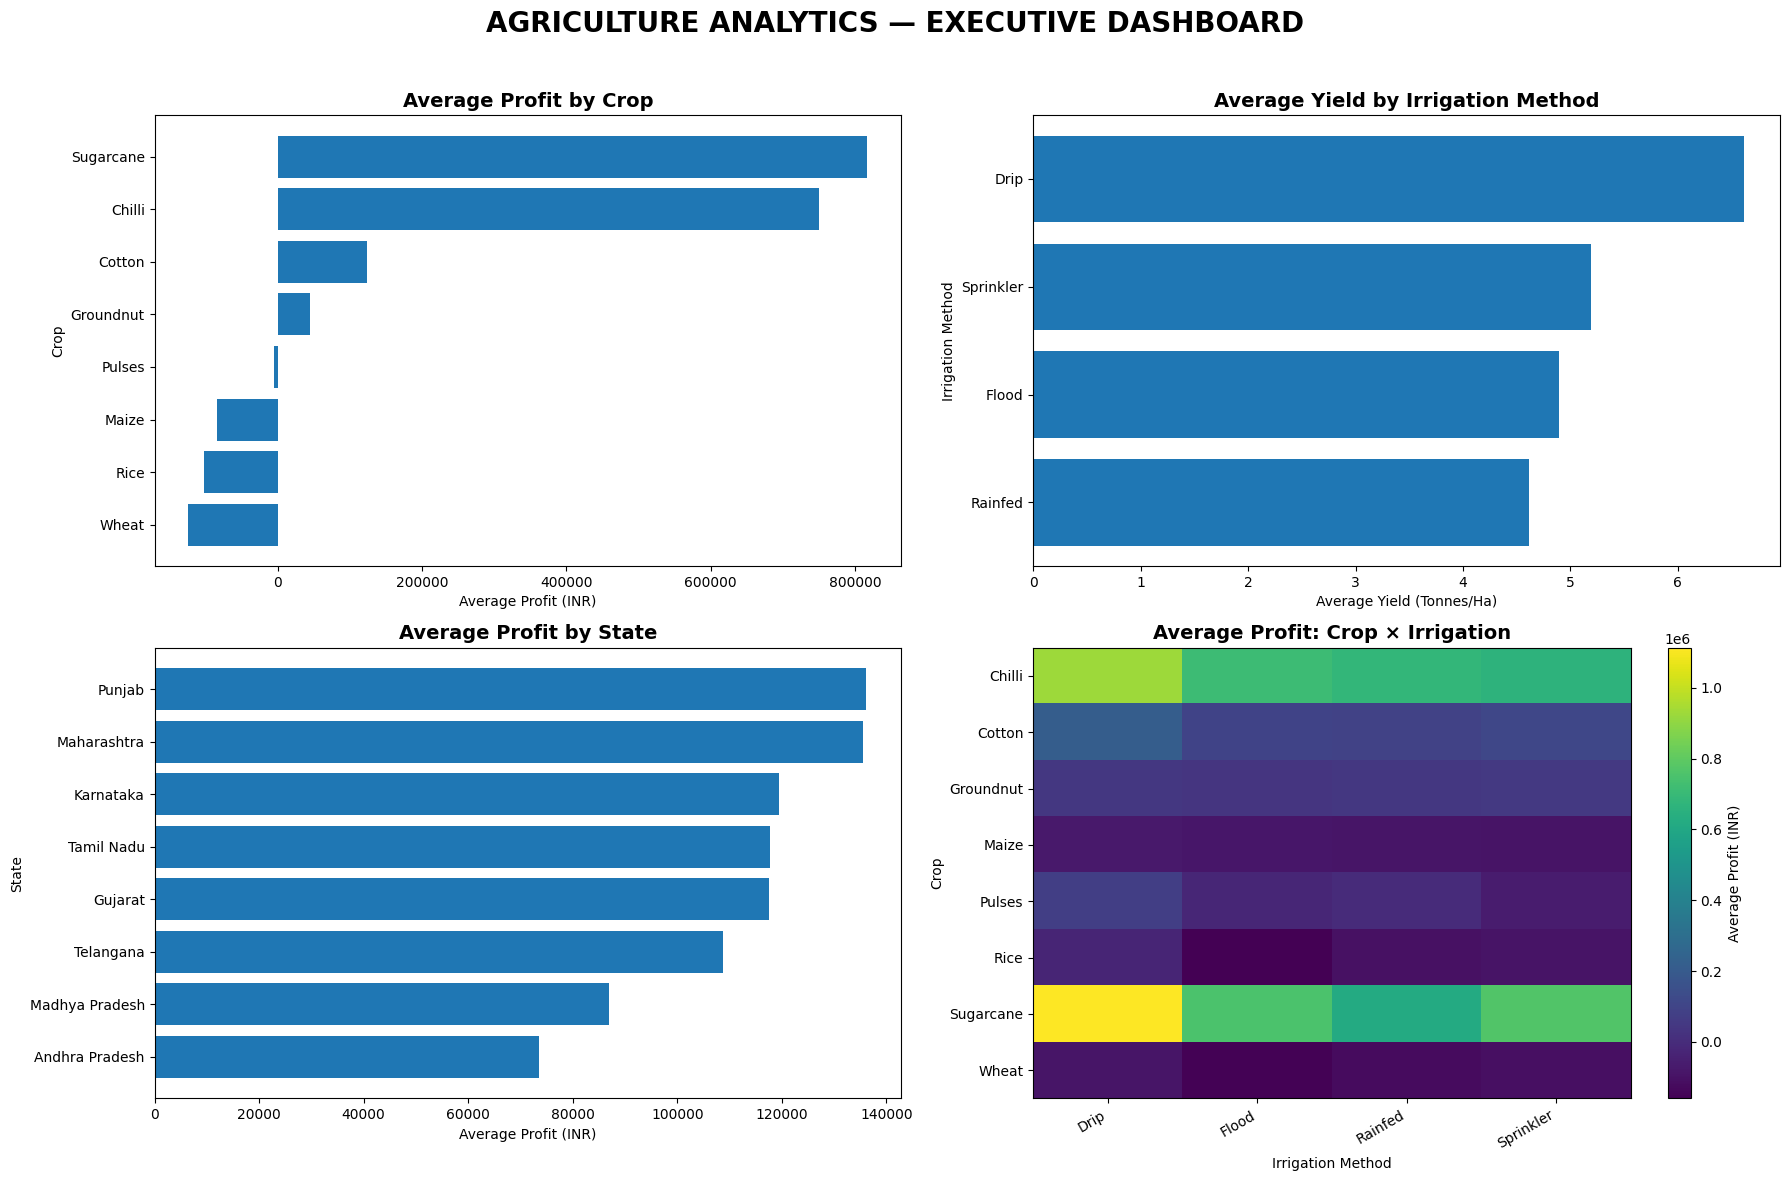

In [49]:
# ============================================================
# 4. FINAL AGRICULTURE ANALYTICS DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Create dashboard figure
fig = plt.figure(figsize=(18, 12))

# ------------------------------------------------------------
# 1. CROP PROFITABILITY
# ------------------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

crop_plot = crop_profit_final.sort_values(
    "Avg_Profit", ascending=True
)

ax1.barh(
    crop_plot.index,
    crop_plot["Avg_Profit"]
)

ax1.set_title(
    "Average Profit by Crop",
    fontsize=14,
    fontweight="bold"
)
ax1.set_xlabel("Average Profit (INR)")
ax1.set_ylabel("Crop")

# ------------------------------------------------------------
# 2. IRRIGATION PERFORMANCE
# ------------------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

irrigation_plot = irrigation_final.sort_values(
    "Avg_Yield",
    ascending=True
)

ax2.barh(
    irrigation_plot.index,
    irrigation_plot["Avg_Yield"]
)

ax2.set_title(
    "Average Yield by Irrigation Method",
    fontsize=14,
    fontweight="bold"
)
ax2.set_xlabel("Average Yield (Tonnes/Ha)")
ax2.set_ylabel("Irrigation Method")

# ------------------------------------------------------------
# 3. STATE PROFITABILITY
# ------------------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

state_profit = (
    df.groupby("State")["Profit_INR"]
      .mean()
      .sort_values()
)

ax3.barh(
    state_profit.index,
    state_profit.values
)

ax3.set_title(
    "Average Profit by State",
    fontsize=14,
    fontweight="bold"
)
ax3.set_xlabel("Average Profit (INR)")
ax3.set_ylabel("State")

# ------------------------------------------------------------
# 4. CROP × IRRIGATION PROFIT
# ------------------------------------------------------------

ax4 = plt.subplot(2, 2, 4)

dashboard_pivot = pd.pivot_table(
    df,
    values="Profit_INR",
    index="Crop",
    columns="Irrigation_Method",
    aggfunc="mean"
)

im = ax4.imshow(
    dashboard_pivot,
    aspect="auto"
)

ax4.set_title(
    "Average Profit: Crop × Irrigation",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Irrigation Method")
ax4.set_ylabel("Crop")

ax4.set_xticks(range(len(dashboard_pivot.columns)))
ax4.set_xticklabels(
    dashboard_pivot.columns,
    rotation=30,
    ha="right"
)

ax4.set_yticks(range(len(dashboard_pivot.index)))
ax4.set_yticklabels(dashboard_pivot.index)

fig.colorbar(
    im,
    ax=ax4,
    label="Average Profit (INR)"
)

# ------------------------------------------------------------
# MAIN TITLE
# ------------------------------------------------------------

fig.suptitle(
    "AGRICULTURE ANALYTICS — EXECUTIVE DASHBOARD",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

## 17. Final Conclusion

Summarize the major findings and the recommended decision framework.

In [50]:
# ============================================================
# FINAL PROJECT CONCLUSION
# ============================================================

print("=" * 75)
print("              AGRICULTURE ANALYTICS — FINAL CONCLUSION")
print("=" * 75)

print("""
KEY FINDINGS
------------

1. CROP PROFITABILITY
   Sugarcane is the most profitable crop with an average profit
   of ₹817,187.99 per farm and an average yield of 46.94 tonnes/ha.

2. IRRIGATION PERFORMANCE
   Drip irrigation delivers the highest average yield at
   6.62 tonnes/ha and the highest average profit at ₹219,626.00.

3. WATER EFFICIENCY
   Rainfed irrigation has the highest water efficiency at
   7.56 tonnes per 1,000 m³ of water.

4. STATE PERFORMANCE
   Punjab records the highest average profit among the analyzed
   states, while Gujarat + Sugarcane + Drip is the strongest
   reliable state-crop-irrigation combination by profit margin.

5. YIELD DRIVERS
   Nitrogen has the strongest positive correlation with yield
   among the listed agricultural inputs.

6. PROFIT DRIVERS
   Revenue has the strongest correlation with profit (0.887),
   followed by Production (0.554) and Yield (0.490).

7. BUSINESS OPPORTUNITY
   Sugarcane and Chilli show strong profitability and margins,
   while Wheat, Rice and Maize require closer investigation
   because their average profits are negative.

FINAL RECOMMENDATION
--------------------
Farm-level decisions should balance profitability, yield and
water efficiency. High-performing crop and irrigation combinations
should be prioritized, while low-profit crops should be reviewed
for production costs, pricing and resource allocation.
""")

print("=" * 75)
print("                 PROJECT COMPLETE")
print("=" * 75)

              AGRICULTURE ANALYTICS — FINAL CONCLUSION

KEY FINDINGS
------------

1. CROP PROFITABILITY
   Sugarcane is the most profitable crop with an average profit
   of ₹817,187.99 per farm and an average yield of 46.94 tonnes/ha.

2. IRRIGATION PERFORMANCE
   Drip irrigation delivers the highest average yield at
   6.62 tonnes/ha and the highest average profit at ₹219,626.00.

3. WATER EFFICIENCY
   Rainfed irrigation has the highest water efficiency at
   7.56 tonnes per 1,000 m³ of water.

4. STATE PERFORMANCE
   Punjab records the highest average profit among the analyzed
   states, while Gujarat + Sugarcane + Drip is the strongest
   reliable state-crop-irrigation combination by profit margin.

5. YIELD DRIVERS
   Nitrogen has the strongest positive correlation with yield
   among the listed agricultural inputs.

6. PROFIT DRIVERS
   Revenue has the strongest correlation with profit (0.887),
   followed by Production (0.554) and Yield (0.490).

7. BUSINESS OPPORTUNITY
   Sug